In [257]:
import matplotlib.pyplot as plt 
import numpy as np 
import cv2 as cv

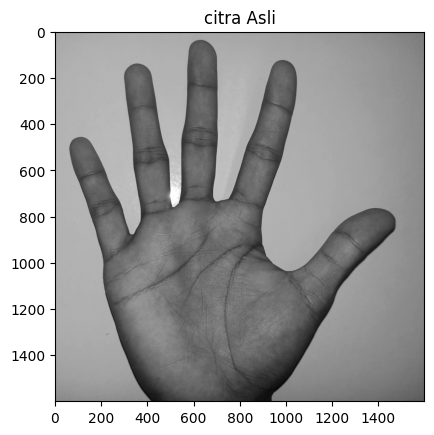

In [258]:
tangan = cv.imread("tangan.jpeg")
tangan = cv.cvtColor(tangan, cv.COLOR_BGR2GRAY)
plt.title("citra Asli")
plt.imshow(tangan, cmap='gray')


In [259]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

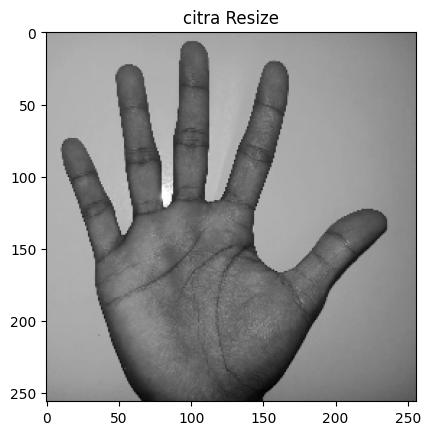

In [260]:
tangan = resize(tangan, 256, 256)
plt.title("citra Resize")
plt.imshow(tangan, cmap='gray')

In [261]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad = size // 2
    padded = np.pad(img, pad, mode='constant')
    h, w = img.shape[:2]
    hasil = np.zeros_like(img).astype(np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            hasil[i, j] = np.sum(region * kernel)
    return hasil


In [262]:
def sobel_edge_detection(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
    Ix = convolution(img, Kx)
    Iy = convolution(img, Ky)
    magnitude = np.sqrt(Ix**2 + Iy**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)


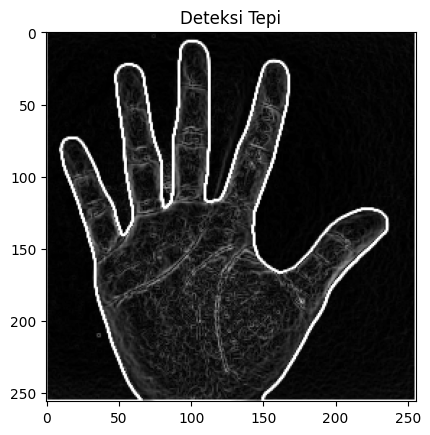

In [263]:
tanganDeteksi = sobel_edge_detection(tangan)
plt.title("Deteksi Tepi")
plt.imshow(tanganDeteksi, cmap='gray')

In [264]:
def thresholding(img, threshold):
    rows, cols = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(rows):
        for j in range(cols):
            if(img[i,j] > threshold):
                canvas[i,j] = 255
            elif(img[i,j] <= threshold):
                canvas[i,j] = 0
    return canvas

def threshold(image, value, min_val, max_val):
    img = np.array(image)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] <= value:
                img[i, j] = max_val
            else:
                img[i, j] = min_val 
    return img


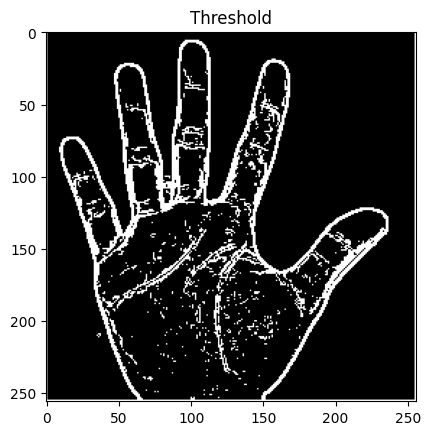

In [265]:
tanganThres = thresholding(tanganDeteksi, 60)
plt.title("Threshold")
plt.imshow(tanganThres, cmap='gray')

In [266]:
kernel_diamond = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
], dtype=np.uint8)

kernel_cross = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)

kernel_cross_satu = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.uint8)

kernel_kotak = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
], dtype=np.uint8) 

kernel_x = np.array([
    [1,0,0,0,1],
    [0,1,0,1,0],
    [0,0,1,0,0],
    [0,1,0,1,0],
    [1,0,0,0,1]
], dtype=np.uint8)

kernel = np.ones((3, 3), np.uint8)

In [267]:
def dilation(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    result = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            result[i+k-center, j+l-center] = 255
            else:
                if result[i,j] != 255:
                    result[i,j] = 0
    return result

def erosion(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    result = np.zeros_like(image, dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            match = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        match = False
                        break
                if not match:
                    break
            if match:
                result[i, j] = 255
    return result

def thinning(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True
    while changed:
        changed = False
        to_delete = []
        # STEP 1
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                neighbors = [P2,P3,P4,P5,P6,P7,P8,P9]
                sum_neighbors = np.sum(neighbors)
                transitions = 0
                sequence = neighbors + [P2]
                for k in range(8):
                    if sequence[k] == 0 and sequence[k+1] == 1:
                        transitions += 1
                if (
                    2 <= sum_neighbors <= 6 and
                    transitions == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    to_delete.append((i,j))
        if to_delete:
            changed = True
            for i,j in to_delete:
                binary[i,j] = 0
            to_delete = []
        # STEP 2
        for i in range(1, height-1):
            for j in range(1, width-1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue
                P2 = binary[i-1, j]
                P3 = binary[i-1, j+1]
                P4 = binary[i, j+1]
                P5 = binary[i+1, j+1]
                P6 = binary[i+1, j]
                P7 = binary[i+1, j-1]
                P8 = binary[i, j-1]
                P9 = binary[i-1, j-1]
                neighbors = [P2,P3,P4,P5,P6,P7,P8,P9]
                sum_neighbors = np.sum(neighbors)
                transitions = 0
                sequence = neighbors + [P2]
                for k in range(8):
                    if sequence[k] == 0 and sequence[k+1] == 1:
                        transitions += 1
                if (
                    2 <= sum_neighbors <= 6 and
                    transitions == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    to_delete.append((i,j))
        if to_delete:
            changed = True
            for i,j in to_delete:
                binary[i,j] = 0
    return binary * 255

def thickening(img, kernel, iterations=1):
    result = img.copy()
    for _ in range(iterations):
        result = dilation(result, kernel)
    return result

def morphological_gradient(img, kernel):
    dilated = dilation(img, kernel)
    eroded = erosion(img, kernel)
    gradient = dilated.astype(np.int16) - eroded.astype(np.int16)
    return np.clip(gradient, 0, 255).astype(np.uint8)

def opening(image, kernel):
    return dilation(erosion(image, kernel), kernel)

def closing(image, kernel):
    return erosion(dilation(image, kernel), kernel)

def gradien_morph(image, kernel):
    return dilation(image, kernel) - erosion(image, kernel)

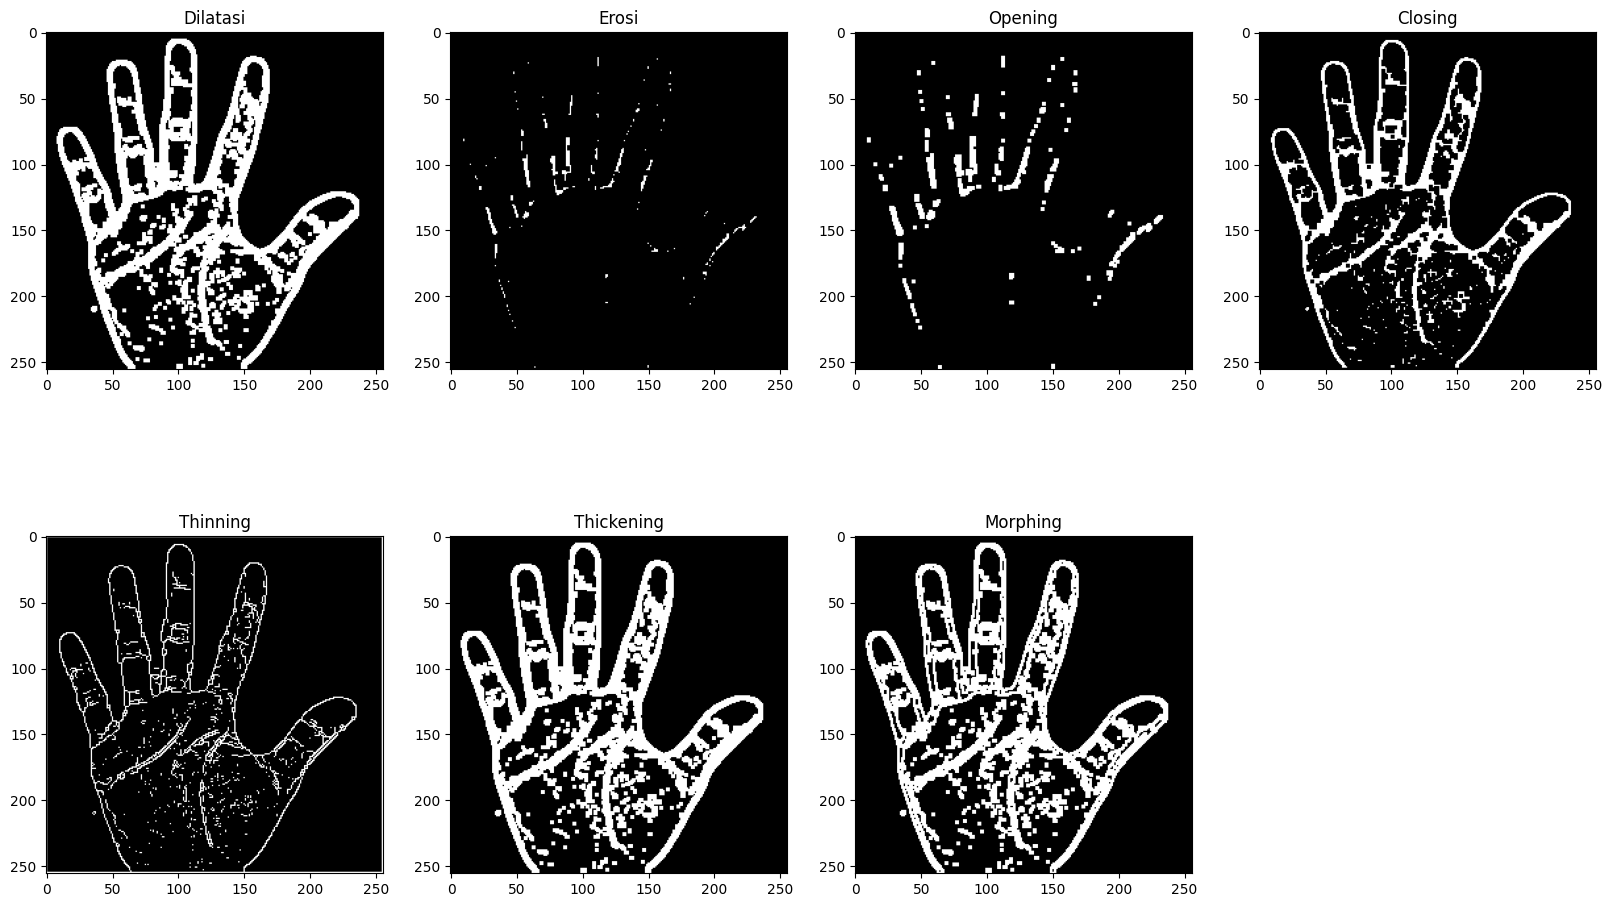

In [268]:
tangan_dilatasi = dilation(tanganThres, kernel_cross_satu)
tangan_erosi = erosion(tanganThres, kernel_cross_satu)
tangan_opening = dilation(tangan_erosi, kernel_cross_satu)
tangan_closing = erosion(tangan_dilatasi, kernel_cross_satu)
tangan_thinning = thinning(tanganThres)
tangan_thickening = thickening(tanganThres, kernel_cross_satu)
tangan_morph = morphological_gradient(tanganThres, kernel_cross_satu)

plt.figure(figsize=(20, 12))

plt.subplot(2, 4, 1)
plt.title("Dilatasi")
plt.imshow(tangan_dilatasi, cmap='gray')
plt.subplot(2, 4, 2)
plt.title("Erosi")
plt.imshow(tangan_erosi, cmap='gray')
plt.subplot(2, 4, 3)
plt.title("Opening")
plt.imshow(tangan_opening, cmap='gray')
plt.subplot(2, 4, 4)
plt.title("Closing")
plt.imshow(tangan_closing, cmap='gray')
plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(tangan_thinning, cmap='gray')
plt.subplot(2, 4, 6)
plt.title("Thickening")
plt.imshow(tangan_thickening, cmap='gray')
plt.subplot(2, 4, 7)
plt.title("Morphing")
plt.imshow(tangan_morph, cmap='gray')

berdasarkan kode diatas, kita bisa melihat bahwa dilasi ialah meningkatkann efek garis garis tersebut, erosi mengikis garis garis yang ada sehingga terlihat seperti garis yang sempit, opening dilakukan dengan cara melakukan erosi terlebih dahulu baru dilasi kemudian, closing adalah kebalikan dari opening dimana kita akan melakukan dilasi terlebih dahulu baru kita erosi kemudian

kita menggunakan kernel ukuran 3x3 dengan setiap isi kernel adalah 1

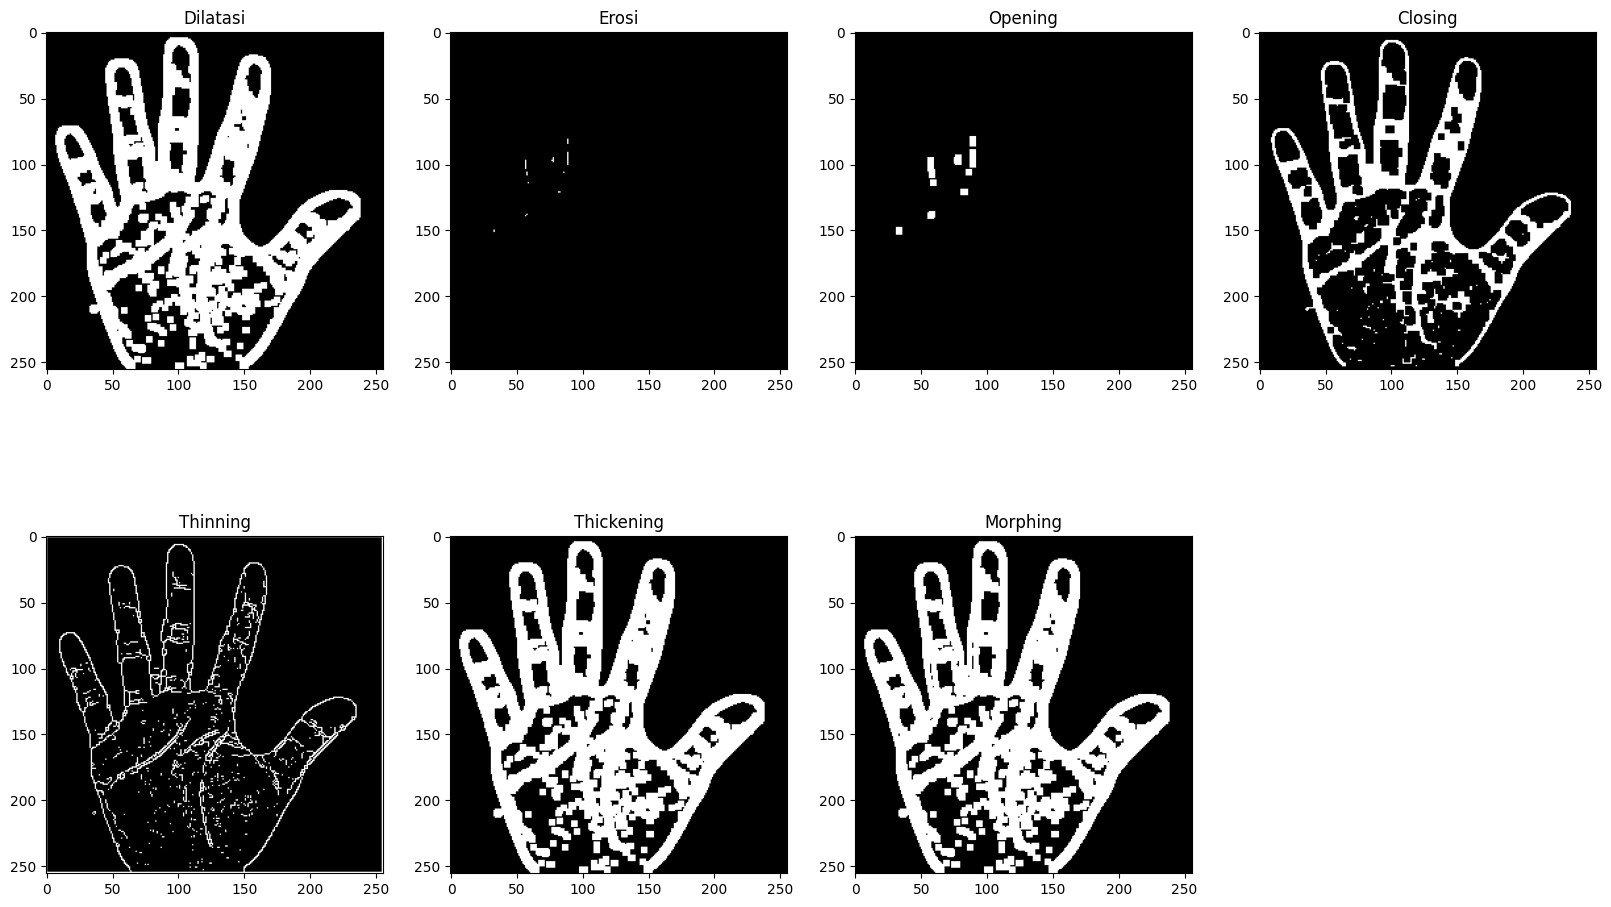

In [269]:
tangan_dilatasi5 = dilation(tanganThres, kernel_kotak)
tangan_erosi5 = erosion(tanganThres, kernel_kotak)
tangan_opening5 = dilation(tangan_erosi5, kernel_kotak)
tangan_closing5 = erosion(tangan_dilatasi5, kernel_kotak)
tangan_thinning5 = thinning(tanganThres)
tangan_thickening5 = thickening(tanganThres, kernel_kotak)
tangan_morph5 = morphological_gradient(tanganThres, kernel_kotak)

plt.figure(figsize=(20, 12))

plt.subplot(2, 4, 1)
plt.title("Dilatasi")
plt.imshow(tangan_dilatasi5, cmap='gray')
plt.subplot(2, 4, 2)
plt.title("Erosi")
plt.imshow(tangan_erosi5, cmap='gray')
plt.subplot(2, 4, 3)
plt.title("Opening")
plt.imshow(tangan_opening5, cmap='gray')
plt.subplot(2, 4, 4)
plt.title("Closing")
plt.imshow(tangan_closing5, cmap='gray')
plt.subplot(2, 4, 5)
plt.title("Thinning")
plt.imshow(tangan_thinning5, cmap='gray')
plt.subplot(2, 4, 6)
plt.title("Thickening")
plt.imshow(tangan_thickening5, cmap='gray')
plt.subplot(2, 4, 7)
plt.title("Morphing")
plt.imshow(tangan_morph5, cmap='gray')

berdasarkan kode diatas, kita bisa melihat bahwa dilasi ialah meningkatkann efek garis garis tersebut, erosi mengikis garis garis yang ada sehingga terlihat seperti garis yang sempit, opening dilakukan dengan cara melakukan erosi terlebih dahulu baru dilasi kemudian, closing adalah kebalikan dari opening dimana kita akan melakukan dilasi terlebih dahulu baru kita erosi kemudian
kita menggunakan kernel ukuran 5x5 dengan setiap isi kernel adalah 1

Opening = erosi, dilasi

Closing = dilasi, erosi

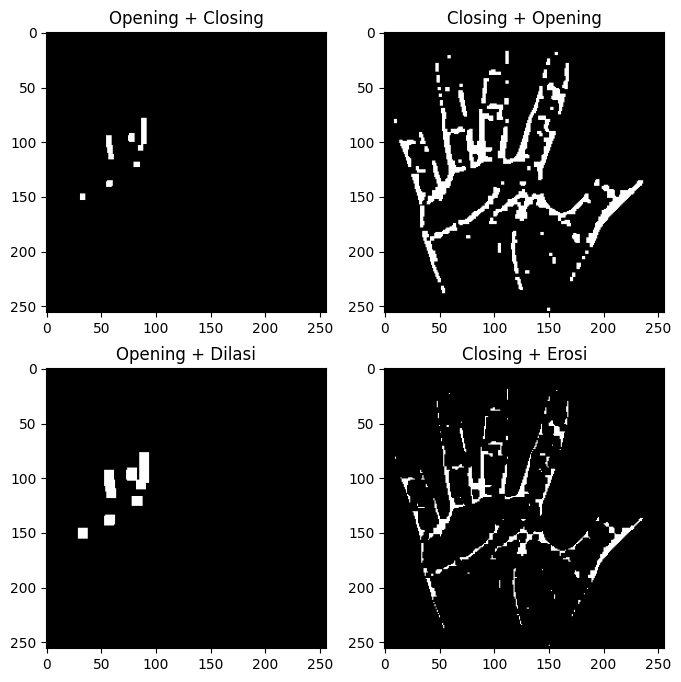

In [270]:
telapakKiriAtas = closing(tangan_opening5, kernel_kotak)
telapakKiriBawah = dilation(tangan_opening5, kernel_kotak)
telapakKananAtas = opening(tangan_closing, kernel_cross_satu)
telapakKananBawah = erosion(tangan_closing, kernel_cross_satu)

plt.figure(figsize=(8, 8))
plt.subplot(2, 2, 1)
plt.title("Opening + Closing")
plt.imshow(telapakKiriAtas, cmap='gray')
plt.subplot(2, 2, 2)
plt.title("Closing + Opening")
plt.imshow(telapakKananAtas, cmap='gray')

plt.subplot(2, 2, 3)
plt.title("Opening + Dilasi")
plt.imshow(telapakKiriBawah, cmap='gray')
plt.subplot(2, 2, 4)
plt.title("Closing + Erosi")
plt.imshow(telapakKananBawah, cmap='gray')

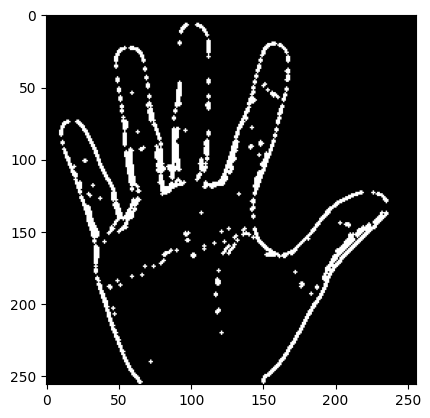

In [276]:
eksplore = opening(tanganThres, kernel_cross)
eksplore = opening(eksplore, kernel_cross)

plt.imshow(eksplore, cmap='gray')